# Opciones Call y Put 
## Simulación de Procesos Financieros

Ximena Muñoz

2/09/26

## 1. Payoff de una Call y una Put

En primer lugar, se analiza la ganancia de una opción Call y una opción Put en función del precio de la acción al vencimiento.

Se considera un precio de ejercicio de:

\[
K = 100
\]

y se analiza un rango de precios de la acción entre 50 y 200.

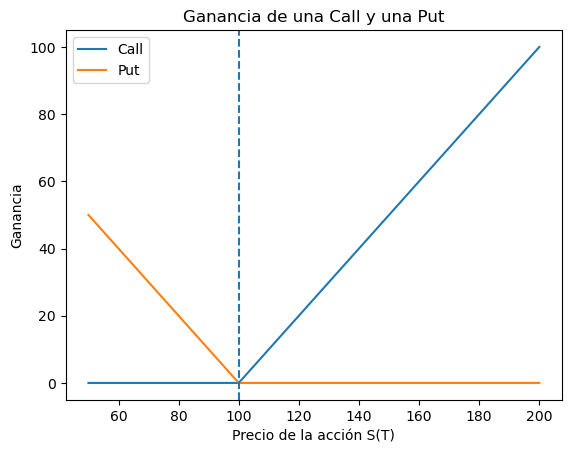

In [1]:
import numpy as np
import matplotlib.pyplot as plt

K = 100

S = np.arange(50, 201)

ganancia_call = np.maximum(S - K, 0)
ganancia_put = np.maximum(K - S, 0)

plt.plot(S, ganancia_call, label="Call")
plt.plot(S, ganancia_put, label="Put")

plt.axvline(K, linestyle="--")

plt.xlabel("Precio de la acción S(T)")
plt.ylabel("Ganancia")
plt.title("Ganancia de una Call y una Put")
plt.legend()

plt.show()

## 2. Simulación del precio de la acción

Para analizar las ganancias de las opciones, se simulan diferentes posibles precios de la acción al vencimiento \(S(T)\).

Se utilizan los siguientes parámetros:

- Precio inicial: \(S_0 = 100\)
- Precio de ejercicio: \(K = 100\)
- Tasa libre de riesgo: \(r = 5\%\)
- Volatilidad: \(sigma = 20\%\)
- Tiempo al vencimiento: \(T = 1\) año
- Número de simulaciones: \(M = 10,000\)

El precio final se simula mediante un movimiento geométrico browniano.

In [2]:
S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1
M = 10000

Z = np.random.normal(0, 1, M)

ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

### Histograma de los precios simulados

El siguiente histograma muestra la distribución de los posibles precios de la acción al vencimiento \(S(T)\) obtenidos mediante las 10,000 simulaciones.

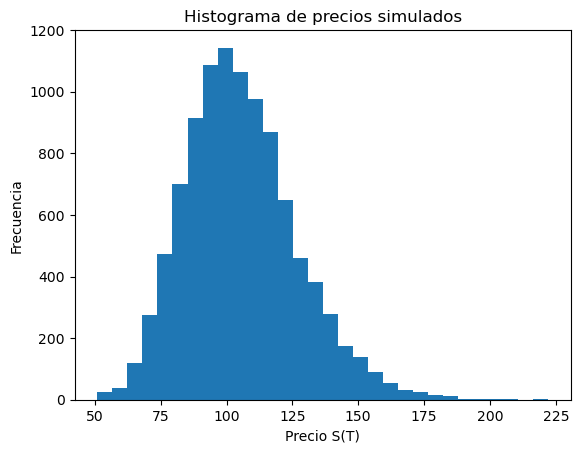

In [3]:
plt.hist(ST, bins=30)

plt.xlabel("Precio S(T)")
plt.ylabel("Frecuencia")
plt.title("Histograma de precios simulados")

plt.show()

# 3. Precio justo de una Call y una Put mediante Monte Carlo

Una vez simulados los posibles precios de la acción al vencimiento, se calcula el payoff de una Call y una Put para cada simulación.

El payoff de una Call es:

$[
\max(S(T)-K,0)
]$

El payoff de una Put es:

$[
\max(K-S(T),0)
]$

Para obtener el precio justo de la opción mediante Monte Carlo, se calcula el promedio de los payoffs y posteriormente se descuenta a valor presente utilizando la tasa libre de riesgo.

In [4]:
ganancia_call = np.maximum(ST - K, 0)
ganancia_put = np.maximum(K - ST, 0)

precio_call_MC = np.exp(-r*T) * np.mean(ganancia_call)
precio_put_MC = np.exp(-r*T) * np.mean(ganancia_put)

print("Precio Call mediante Monte Carlo:", precio_call_MC)
print("Precio Put mediante Monte Carlo:", precio_put_MC)

Precio Call mediante Monte Carlo: 10.666686350073306
Precio Put mediante Monte Carlo: 5.4133755628844975


### Histograma del payoff de Long Put

A continuación se muestra la distribución de los payoffs obtenidos para la posición Long Put en las 10,000 simulaciones.

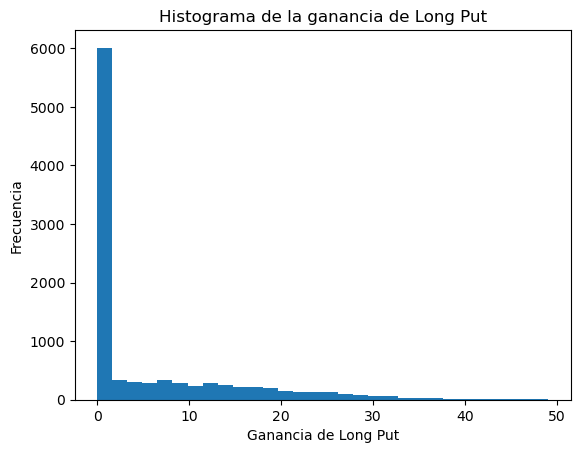

In [5]:
plt.hist(ganancia_put, bins=30)

plt.xlabel("Ganancia de Long Put")
plt.ylabel("Frecuencia")
plt.title("Histograma de la ganancia de Long Put")

plt.show()

### Histograma del payoff de Long Call

A continuación se muestra la distribución de los payoffs obtenidos para la posición Long Call en las 10,000 simulaciones.

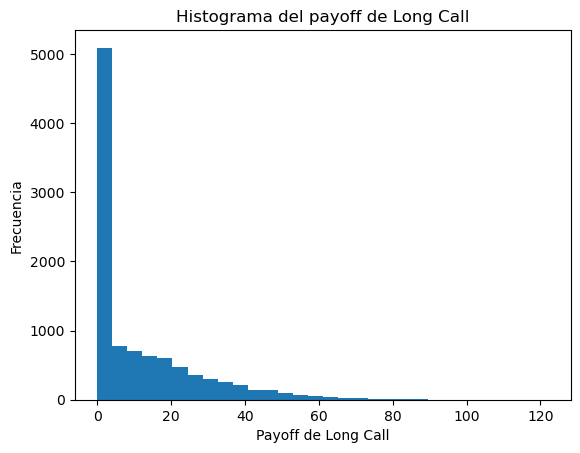

In [6]:
plt.hist(ganancia_call, bins=30)

plt.xlabel("Payoff de Long Call")
plt.ylabel("Frecuencia")
plt.title("Histograma del payoff de Long Call")

plt.show()

## 4. Precio de las opciones mediante Black-Scholes

Para comparar el resultado obtenido mediante Monte Carlo, se calcula también el precio de una Call y una Put utilizando el modelo de Black-Scholes.

Primero se calculan:

$
d_1 =
\frac{\ln(S_0/K)+(r+\sigma^2/2)T}
{\sigma\sqrt{T}}
$

y

$
d_2=d_1-\sigma\sqrt{T}
$

El precio de la Call es:

$
C=S_0N(d_1)-Ke^{-rT}N(d_2)
$

El precio de la Put es:

$
P=Ke^{-rT}N(-d_2)-S_0N(-d_1)
$

donde \(N(\cdot)\) representa la función de distribución acumulada de una distribución normal estándar.

In [7]:
from scipy.stats import norm

d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

d2 = d1 - sigma*np.sqrt(T)

precio_call_BS = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

precio_put_BS = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

print("Precio Call Black-Scholes:", precio_call_BS)
print("Precio Put Black-Scholes:", precio_put_BS)

Precio Call Black-Scholes: 10.450583572185565
Precio Put Black-Scholes: 5.573526022256971


## Comparación de resultados

Se comparan los precios obtenidos mediante la simulación de Monte Carlo con los precios calculados mediante la fórmula de Black-Scholes.

In [8]:
import pandas as pd

comparacion = pd.DataFrame({
    "Opción": ["Call", "Put"],
    "Monte Carlo": [precio_call_MC, precio_put_MC],
    "Black-Scholes": [precio_call_BS, precio_put_BS]
})

comparacion["Diferencia"] = (
    comparacion["Monte Carlo"] - comparacion["Black-Scholes"]
)

comparacion

,Opción,Monte Carlo,Black-Scholes,Diferencia
0,Call,10.666686,10.450584,0.216103
1,Put,5.413376,5.573526,-0.160150


# 5. Sensibilidad

## 5.1 Efecto del precio del activo

Se analiza cómo cambia el precio de una Call y una Put cuando cambia el precio inicial del activo.

Se consideran los siguientes precios:

- 80
- 90
- 100
- 110
- 120

Se mantienen constantes los demás parámetros:

- \(K=100\)
- \(r=5\%\)
- \(sigma=20\%\)
- \(T=1\)
- \(M=10,000\)

In [9]:
S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1
M = 10000

precios_activo = [80, 90, 100, 110, 120]

resultados_S0_call = []
resultados_S0_put = []

for S0 in precios_activo:
    
    Z = np.random.normal(0, 1, M)
    
    ST = S0 * np.exp(
        (r - 0.5*sigma**2)*T
        + sigma*np.sqrt(T)*Z
    )
    
    ganancia_call = np.maximum(ST-K, 0)
    ganancia_put = np.maximum(K-ST, 0)
    
    precio_call = np.exp(-r*T) * np.mean(ganancia_call)
    precio_put = np.exp(-r*T) * np.mean(ganancia_put)
    
    resultados_S0_call.append(precio_call)
    resultados_S0_put.append(precio_put)

In [10]:
import pandas as pd

tabla_S0 = pd.DataFrame({
    "Precio del activo": precios_activo,
    "Precio Call": resultados_S0_call,
    "Precio Put": resultados_S0_put
})

tabla_S0

,Precio del activo,Precio Call,Precio Put
0,80,1.855982,16.812431
1,90,4.986170,10.245093
2,100,10.678077,5.537324
3,110,17.475309,2.698019
4,120,26.289850,1.280513


### 5.2 Efecto del precio de ejercicio (Strike)

Se analiza cómo cambia el precio de una Call y una Put cuando cambia el precio de ejercicio \(K\).

Se consideran los siguientes precios de ejercicio:

- 80
- 90
- 100
- 110
- 120

Se mantienen constantes los demás parámetros.

In [11]:
S0 = 100
r = 0.05
sigma = 0.20
T = 1
M = 10000

strikes = [80, 90, 100, 110, 120]

resultados_K_call = []
resultados_K_put = []

for K in strikes:
    
    Z = np.random.normal(0, 1, M)
    
    ST = S0 * np.exp(
        (r - 0.5*sigma**2)*T
        + sigma*np.sqrt(T)*Z
    )
    
    ganancia_call = np.maximum(ST-K, 0)
    ganancia_put = np.maximum(K-ST, 0)
    
    precio_call = np.exp(-r*T) * np.mean(ganancia_call)
    precio_put = np.exp(-r*T) * np.mean(ganancia_put)
    
    resultados_K_call.append(precio_call)
    resultados_K_put.append(precio_put)

In [12]:
import pandas as pd

tabla_K = pd.DataFrame({
    "Strike": strikes,
    "Precio Call": resultados_K_call,
    "Precio Put": resultados_K_put
})

tabla_K

,Strike,Precio Call,Precio Put
0,80,24.435130,0.702937
1,90,16.510770,2.389603
2,100,10.425203,5.668177
3,110,5.984512,10.566306
4,120,3.224057,17.558764


### 5.3 Efecto de la volatilidad

Se analiza cómo cambia el precio de una Call y una Put cuando cambia la volatilidad del activo.

Se consideran los siguientes niveles de volatilidad:

- 10%
- 20%
- 30%
- 40%
- 50%

Se mantienen constantes los demás parámetros.

In [13]:
S0 = 100
K = 100
r = 0.05
T = 1
M = 10000

volatilidades = [0.10, 0.20, 0.30, 0.40, 0.50]

resultados_sigma_call = []

resultados_sigma_put = []

for sigma in volatilidades:
    
    Z = np.random.normal(0, 1, M)
    
    ST = S0 * np.exp(
        (r - 0.5*sigma**2)*T
        + sigma*np.sqrt(T)*Z
    )
    
    ganancia_call = np.maximum(ST-K, 0)
    ganancia_put = np.maximum(K-ST, 0)
    
    precio_call = np.exp(-r*T) * np.mean(ganancia_call)
    precio_put = np.exp(-r*T) * np.mean(ganancia_put)
    
    resultados_sigma_call.append(precio_call)
    resultados_sigma_put.append(precio_put)

In [14]:
import pandas as pd

tabla_sigma = pd.DataFrame({
    "Volatilidad": [f"{sigma*100:.0f}%" for sigma in volatilidades],
    "Precio Call": resultados_sigma_call,
    "Precio Put": resultados_sigma_put
})

tabla_sigma

,Volatilidad,Precio Call,Precio Put
0,10%,6.625265,1.970405
1,20%,10.744615,5.552863
2,30%,13.924139,9.384267
3,40%,18.168061,13.288648
4,50%,21.720748,16.867912


### 5.4 Efecto del tiempo al vencimiento

Se analiza cómo cambia el precio de una Call y una Put para diferentes tiempos al vencimiento.

Se consideran los siguientes vencimientos:

- 0.25 años
- 0.5 años
- 1 año
- 1.5 años
- 2 años

Se mantienen constantes los demás parámetros.

In [15]:
S0 = 100
K = 100
r = 0.05
sigma = 0.20
M = 10000

tiempos = [0.25, 0.5, 1, 1.5, 2]

resultados_T_call = []
resultados_T_put = []

for T in tiempos:
    
    Z = np.random.normal(0, 1, M)
    
    ST = S0 * np.exp(
        (r - 0.5*sigma**2)*T
        + sigma*np.sqrt(T)*Z
    )
    
    ganancia_call = np.maximum(ST-K, 0)
    ganancia_put = np.maximum(K-ST, 0)
    
    precio_call = np.exp(-r*T) * np.mean(ganancia_call)
    precio_put = np.exp(-r*T) * np.mean(ganancia_put)
    
    resultados_T_call.append(precio_call)
    resultados_T_put.append(precio_put)

In [16]:
import pandas as pd

tabla_T = pd.DataFrame({
    "Tiempo (años)": tiempos,
    "Precio Call": resultados_T_call,
    "Precio Put": resultados_T_put
})

tabla_T

,Tiempo (años),Precio Call,Precio Put
0,0.25,4.508806,3.458837
1,0.50,6.794609,4.365403
2,1.00,10.252601,5.603829
3,1.50,13.442963,6.184461
4,2.00,16.350351,6.461742


### 5.5 Efecto del rendimiento

Se analiza cómo cambia el precio de una Call y una Put cuando cambia la tasa libre de riesgo \(r\).

Se consideran las siguientes tasas:

- 5%
- 10%
- 15%
- 20%

Se mantienen constantes los demás parámetros.

In [17]:
S0 = 100
K = 100
sigma = 0.20
T = 1
M = 10000

tasas = [0.05, 0.10, 0.15, 0.20]

resultados_r_call = []
resultados_r_put = []

for r in tasas:
    
    Z = np.random.normal(0, 1, M)
    
    ST = S0 * np.exp(
        (r - 0.5*sigma**2)*T
        + sigma*np.sqrt(T)*Z
    )
    
    ganancia_call = np.maximum(ST-K, 0)
    ganancia_put = np.maximum(K-ST, 0)
    
    precio_call = np.exp(-r*T) * np.mean(ganancia_call)
    precio_put = np.exp(-r*T) * np.mean(ganancia_put)
    
    resultados_r_call.append(precio_call)
    resultados_r_put.append(precio_put)

In [18]:
import pandas as pd
tabla_r = pd.DataFrame({
    "Tasa": [f"{r*100:.0f}%" for r in tasas],
    "Precio Call": resultados_r_call,
    "Precio Put": resultados_r_put
})

tabla_r

,Tasa,Precio Call,Precio Put
0,5%,10.672145,5.707054
1,10%,13.136417,3.773719
2,15%,16.567306,2.427926
3,20%,19.569932,1.486454


## 6. Visualización

### 6.1 Precio de la opción vs precio del activo

La siguiente gráfica muestra cómo cambia el precio de una Call y una Put cuando cambia el precio inicial del activo.

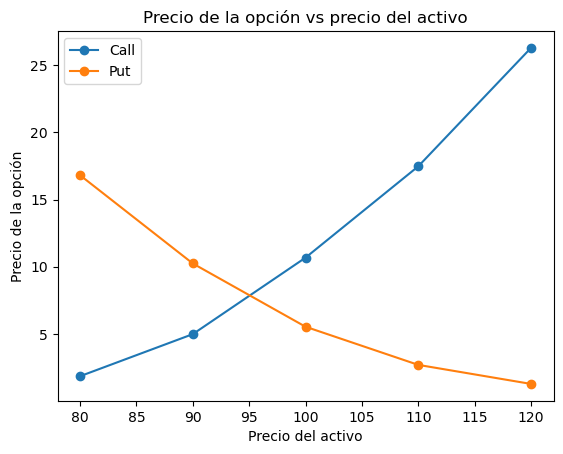

In [19]:
plt.plot(precios_activo, resultados_S0_call, marker="o", label="Call")
plt.plot(precios_activo, resultados_S0_put, marker="o", label="Put")

plt.xlabel("Precio del activo")
plt.ylabel("Precio de la opción")
plt.title("Precio de la opción vs precio del activo")
plt.legend()

plt.show()

### 6.2 Precio de la opción vs Strike

La siguiente gráfica muestra cómo cambia el precio de una Call y una Put cuando cambia el precio de ejercicio.

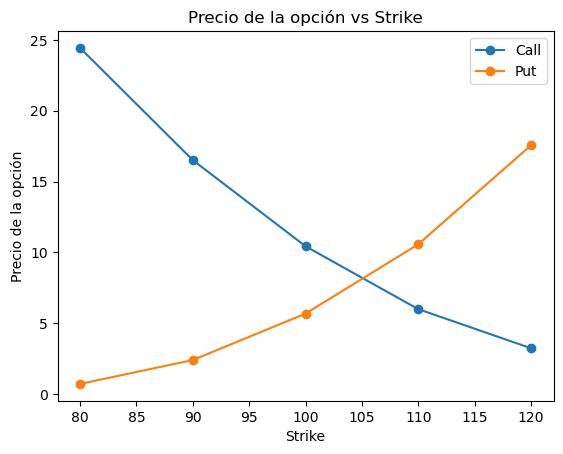

In [20]:
plt.plot(strikes, resultados_K_call, marker="o", label="Call")
plt.plot(strikes, resultados_K_put, marker="o", label="Put")

plt.xlabel("Strike")
plt.ylabel("Precio de la opción")
plt.title("Precio de la opción vs Strike")
plt.legend()

plt.show()

### 6.3 Precio de la opción vs volatilidad

La siguiente gráfica muestra cómo cambia el precio de una Call y una Put cuando aumenta la volatilidad del activo.

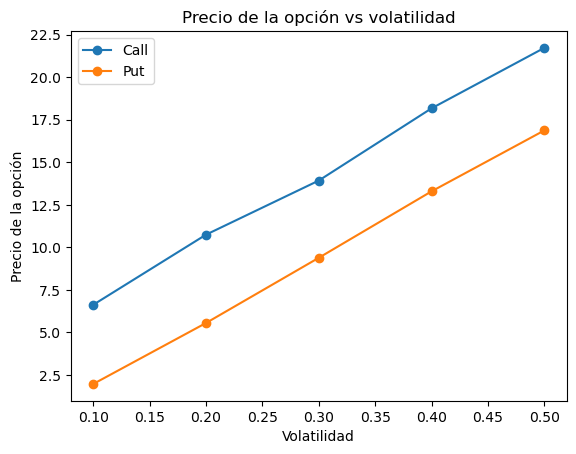

In [21]:
plt.plot(volatilidades, resultados_sigma_call, marker="o", label="Call")
plt.plot(volatilidades, resultados_sigma_put, marker="o", label="Put")

plt.xlabel("Volatilidad")
plt.ylabel("Precio de la opción")
plt.title("Precio de la opción vs volatilidad")
plt.legend()

plt.show()

### 6.4 Precio de la opción vs tiempo

La siguiente gráfica muestra cómo cambia el precio de una Call y una Put cuando aumenta el tiempo al vencimiento.

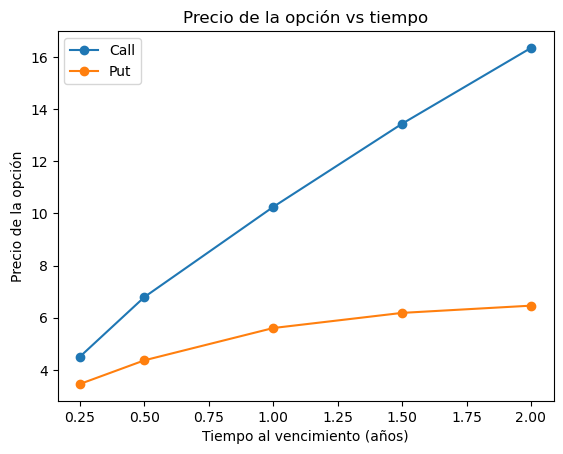

In [22]:
plt.plot(tiempos, resultados_T_call, marker="o", label="Call")
plt.plot(tiempos, resultados_T_put, marker="o", label="Put")

plt.xlabel("Tiempo al vencimiento (años)")
plt.ylabel("Precio de la opción")
plt.title("Precio de la opción vs tiempo")
plt.legend()

plt.show()

### 6.5 Precio de la opción vs rendimiento

La siguiente gráfica muestra cómo cambia el precio de una Call y una Put cuando cambia la tasa libre de riesgo.

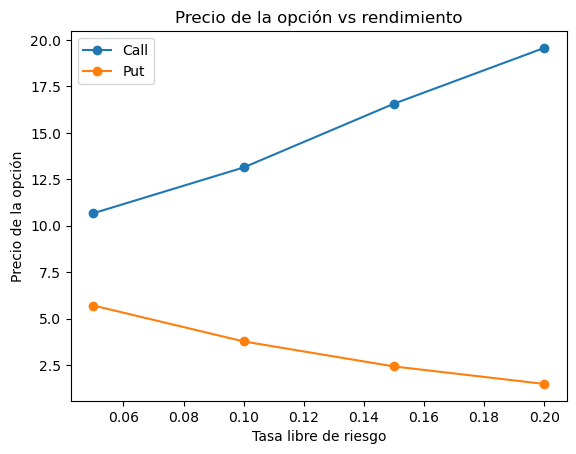

In [23]:
plt.plot(tasas, resultados_r_call, marker="o", label="Call")
plt.plot(tasas, resultados_r_put, marker="o", label="Put")

plt.xlabel("Tasa libre de riesgo")
plt.ylabel("Precio de la opción")
plt.title("Precio de la opción vs rendimiento")
plt.legend()

plt.show()

## 7. Interpretación de los resultados

### Precio del activo
El precio de una Call aumenta cuando aumenta el precio del activo subyacente, porque existe una mayor posibilidad de que la opción termine dentro del dinero (ITM). En cambio, el precio de una Put disminuye, porque resulta menos favorable para el comprador de la Put que el activo tenga un precio elevado.

### Volatilidad
La volatilidad aumenta el valor tanto de la Call como de la Put. Esto sucede porque el payoff de ambas opciones es asimétrico: en el peor de los casos, el comprador de una opción pierde como máximo la prima (el payoff nunca es negativo, ya que siempre se calcula como `max(..., 0)`). Como las pérdidas están limitadas pero las ganancias no, una mayor incertidumbre sobre el precio futuro del activo solo puede ampliar el rango de posibles resultados favorables, sin aumentar el riesgo de pérdida adicional para el comprador. Por eso, a mayor volatilidad, mayor es el valor esperado de ambas opciones.

### Tiempo
En general, un mayor tiempo hasta el vencimiento favorece al comprador de una opción, porque existe más tiempo para que el precio del activo se mueva favorablemente. Sin embargo, esto no significa que sea siempre conveniente para todas las partes, ya que el vendedor de la opción asume la exposición durante más tiempo.

### Strike
El strike (K) es el precio al que el comprador de la opción tiene derecho a comprar (Call) o vender (Put) el activo subyacente. Una opción está **in-the-money (ITM)** cuando, de ejercerse en ese momento, generaría una ganancia positiva para el comprador: una Call está ITM cuando S(T) > K, y una Put está ITM cuando S(T) < K.

El strike modifica directamente la probabilidad de terminar ITM: al aumentar K, es menos probable que el precio final del activo S(T) logre superarlo, por lo que disminuye la probabilidad de que la Call termine ITM y, en consecuencia, su valor baja. Por el contrario, al aumentar K es más probable que S(T) quede por debajo de ese nivel, por lo que aumenta la probabilidad de que la Put termine ITM y su valor sube. Esto es justamente lo que se observa en los resultados de la simulación: la Call disminuye y la Put aumenta conforme el strike crece.

## 8. Comparación con el mercado

Si fuera un inversionista, el parámetro que consideraría más importante monitorear sería la volatilidad.

Esto se debe a que la volatilidad representa la incertidumbre sobre los movimientos futuros del precio del activo y tiene un efecto importante sobre el valor tanto de las Calls como de las Puts. En los resultados de la simulación se observa que, al aumentar la volatilidad, también aumenta el precio de ambas opciones.

Por esta razón, monitorear la volatilidad puede ayudar al inversionista a identificar cómo podrían cambiar los precios de las opciones ante diferentes niveles de incertidumbre en el mercado.

## 9. Conclusiones

Mediante la simulación de Monte Carlo se estimaron los precios de opciones Call y Put y se compararon con los valores obtenidos mediante el modelo de Black-Scholes. Los resultados mostraron que ambos métodos producen precios similares, aunque Monte Carlo presenta pequeñas variaciones debido a la aleatoriedad de la simulación.

Además, el análisis de sensibilidad permitió observar cómo el precio de las opciones cambia ante modificaciones en el precio del activo, strike, volatilidad, tiempo y tasa de rendimiento. En particular, se observó que la volatilidad tiene un efecto importante tanto sobre las Calls como sobre las Puts.

La simulación permitió comprender de manera práctica la relación entre estos parámetros y el valor de las opciones financieras.